In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
NUM_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20] 

attn_scores = {}
pca_scores = {}
shap_scores = {}

for layer in NUM_LAYERS:
    df_attn = pd.read_csv(f"Results/attention_scores/{layer}layers/attention_scores{layer}layers_unsorted.csv")
    df_pca = pd.read_csv(f"Results/attention_scores/{layer}layers/pca_scores{layer}layers_unsorted.csv")
    df_shap = pd.read_csv(f"Results/shap_values/tables/{layer}layers/shap_scores{layer}layers_unsorted.csv")

    attn_scores[layer] = df_attn["score"].to_numpy()
    pca_scores[layer] = df_pca["score"].to_numpy()
    shap_scores[layer] = df_shap["score"].to_numpy()    

### Top-k feature importance

In [3]:
feature_abbrev = ["1,5-AG", "2-AB", "2-HB", "2-OG", "3-HIB", "Acetate", "AcAc", "Acetone", 
                  "Ala", "Alb", "ApoB", "Arg", "Asn", "Asp", "BCAA/AAA", "Bet", "Bili", 
                  "CRP", "Ca", "Cho", "Citrate", "Crn", "Creat", "Cys-Cys", "Gal", 
                  "DMA", "DMSO2", "ESR", "RBC", "eGFR", "EtOH", "Formate", "Gluc", "Glu-ac", 
                  "Gln", "Gln/Glu", "GlycA", "GlycB/A", "Glyc", "Gly", "HDL-C", "His", "Fe", 
                  "LDL-C", "Lac/Pyr", "Lac", "Leu", "WBC", "Lp(a)", "Lys", "MeOH", "Met", 
                  "MI", "DMG", "NAP", "Orn", "Phe", "Plt", "Pro", "Pyr", "SPC", "Sar", 
                  "Ser", "Succ", "Thr", "Tf", "TG", "TMAO", "Tyr", "Urate", "Urea", "Urea/Cr"]

/tmp/ipykernel_85106/4266450372.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


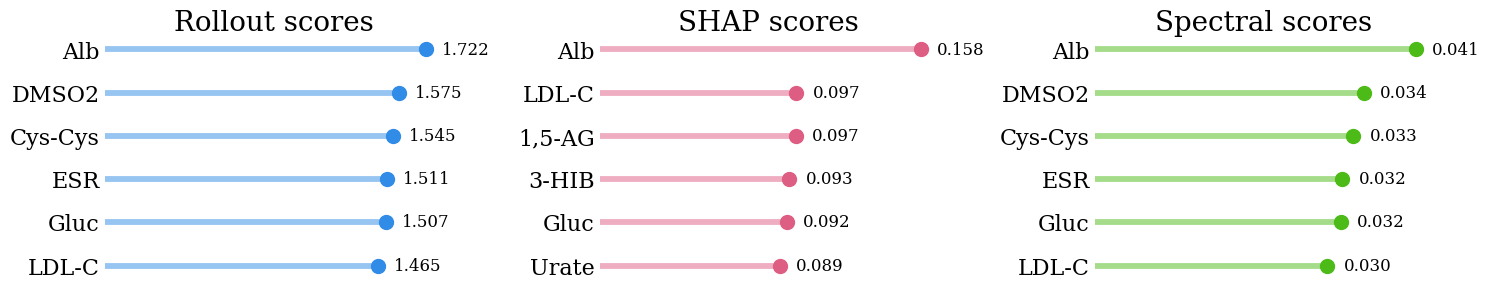

In [4]:
plt.rcParams["font.family"] = "serif"
l = 11

# df_r = pd.read_csv(f"Results/attention_scores/{l}layers/attention_scores{l}layers.csv")
# df_p = pd.read_csv(f"Results/attention_scores/{l}layers/pca_scores{l}layers.csv")
# df_s = pd.read_csv(f"Results/shap_values/tables/{l}layers/shap_scores{l}layers.csv")

df_r = pd.read_csv(f"Results/attention_scores/{l}layers/attention_scores{l}layers_unsorted.csv")
df_p = pd.read_csv(f"Results/attention_scores/{l}layers/pca_scores{l}layers_unsorted.csv")
df_s = pd.read_csv(f"Results/shap_values/tables/{l}layers/shap_scores{l}layers_unsorted.csv")

scores_dict = {"Rollout scores": df_r["score"].to_numpy(),
               "SHAP scores": df_s["score"].to_numpy(),
               "Spectral scores": df_p["score"].to_numpy()}

feature_dict = {"Rollout scores": df_r["feature"].values.tolist(),
                "SHAP scores": df_s["feature"].values.tolist(),
                "Spectral scores": df_p["feature"].values.tolist()}

colors_dict = {"Rollout scores": "#318CE7",
               "SHAP scores": "#DE5D83",
               "Spectral scores": "#4CBB17"}

fig, axes = plt.subplots(1, 3, figsize=(15, 3), constrained_layout=True)

k=6

for ax, (title, scores) in zip(axes, scores_dict.items()):

    # --- Top-k selection ---
    idx = np.argsort(scores)[-k:][::-1]
    top_scores = scores[idx]
    top_features = [feature_abbrev[i] for i in idx]
    # top_features = [feature_dict[title][i] for i in idx]

    # Normalize for visual consistency
    top_scores_norm = top_scores / np.max(top_scores)

    y = np.arange(k)

    # --- Thin horizontal lines ---
    for yi, val in zip(y, top_scores_norm):
        ax.hlines(y=yi, xmin=0, xmax=val, linewidth=4.2, 
                  color=colors_dict[title], alpha=0.5)        
        ax.plot(val, yi, 'o', markersize=10, color=colors_dict[title])

    # --- Labels ---
    ax.set_xticks([])
    ax.set_yticks(y)
    ax.set_yticklabels(top_features, fontsize=16)

    ax.invert_yaxis()

    ax.set_title(title, fontsize=20)

    ax.set_xlim(0, 1.05)

    xmax = top_scores_norm.max()
    for j, value in enumerate(top_scores_norm):        
        ax.text(value + 0.05 * xmax, j, 
                f"{top_scores[j]:.3f}", va="center", 
                fontsize=12)

    # Clean style similar to your figure
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.tick_params(axis='y', length=0)

    ax.grid(False)

plt.tight_layout()

# plt.savefig(f"Results/feature_importance_plots/top{k}scores_L{l}.pdf", bbox_inches="tight")

plt.show()

### Ranking correlation

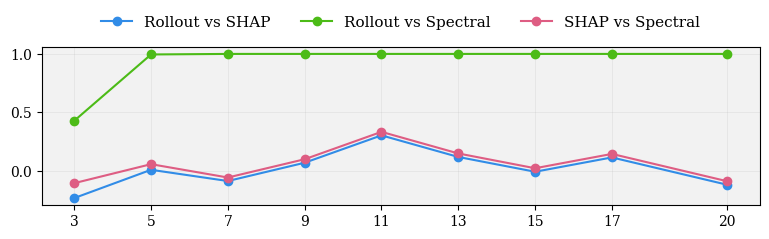

In [5]:
corr_rs = []
corr_rp = []
corr_sp = []

for layer in NUM_LAYERS:
    df_r = pd.read_csv(f"Results/attention_scores/{layer}layers/attention_scores{layer}layers.csv")
    df_s = pd.read_csv(f"Results/shap_values/tables/{layer}layers/shap_scores{layer}layers.csv")
    df_p = pd.read_csv(f"Results/attention_scores/{layer}layers/pca_scores{layer}layers.csv")
   
    r = np.asarray(df_r["original_position"])
    s = np.asarray(df_s["original_position"])
    p = np.asarray(df_p["original_position"])

    corr_rs.append(spearmanr(r, s).correlation)
    corr_rp.append(spearmanr(r, p).correlation)
    corr_sp.append(spearmanr(s, p).correlation + 0.03)

fig, ax = plt.subplots(figsize=(8, 2.5))

plt.plot(NUM_LAYERS, corr_rs, marker="o", label="Rollout vs SHAP", color="#318CE7")
plt.plot(NUM_LAYERS, corr_rp, marker="o", label="Rollout vs Spectral", color="#4CBB17")
plt.plot(NUM_LAYERS, corr_sp, marker="o", label="SHAP vs Spectral", color="#DE5D83")

plt.gca().set_facecolor("#f2f2f2")
plt.grid(True, linewidth=0.4, alpha=0.3)

ax.set_xticks(NUM_LAYERS)

# plt.axhline(0, linewidth=1)
# plt.xlabel("Transformer depth L")
# plt.title("Agreement between feature-importance scores across depth")
# plt.legend()
plt.legend(ncol=3, frameon=False, fontsize=11, 
           loc="lower center", bbox_to_anchor=(0.5, 1.02))


plt.tight_layout()

# plt.savefig("Results/feature_importance_plots/agreement.pdf", bbox_inches="tight")

plt.show()

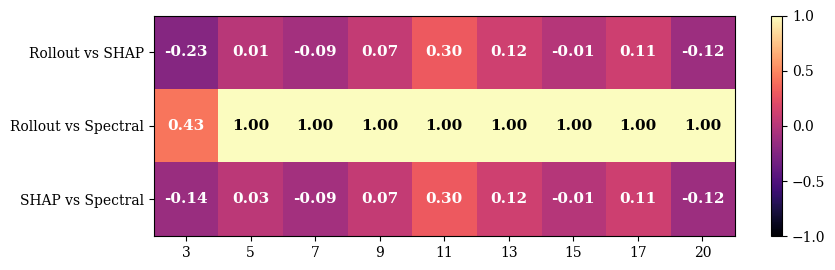

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

corr_rs = []
corr_rp = []
corr_sp = []

cmap = "magma"

for layer in NUM_LAYERS:

    df_r = pd.read_csv(f"Results/attention_scores/{layer}layers/attention_scores{layer}layers.csv")
    df_s = pd.read_csv(f"Results/shap_values/tables/{layer}layers/shap_scores{layer}layers.csv")
    df_p = pd.read_csv(f"Results/attention_scores/{layer}layers/pca_scores{layer}layers.csv")

    r = np.asarray(df_r["original_position"])
    s = np.asarray(df_s["original_position"])
    p = np.asarray(df_p["original_position"])

    corr_rs.append(spearmanr(r, s).correlation)
    corr_rp.append(spearmanr(r, p).correlation)
    corr_sp.append(spearmanr(s, p).correlation)

# Build matrix
heatmap_data = np.array([corr_rs, corr_rp, corr_sp])

fig, ax = plt.subplots(figsize=(9, 2.8))

im = ax.imshow(heatmap_data, aspect="auto", cmap=cmap, 
               vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(range(len(NUM_LAYERS)))
ax.set_xticklabels(NUM_LAYERS)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Rollout vs SHAP", "Rollout vs Spectral", "SHAP vs Spectral"])

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):

        value = heatmap_data[i, j]

        # choose text color depending on intensity
        text_color = "white" if abs(value) < 0.6 else "black"

        ax.text(j, i, f"{value:.2f}", 
                ha="center", va="center", 
                fontsize=11, fontweight="bold",
                color=text_color)

cbar = plt.colorbar(im)
# cbar.set_label("Spearman correlation")
# ax.set_xlabel("Transformer depth L")

plt.tight_layout()

plt.savefig("Results/feature_importance_plots/agreement_heatmap.pdf", bbox_inches="tight")
plt.show()

### Heatmaps
##### Attention

##### Shap

##### Spectral

In [ ]:
selected_features, _ = plot_rank_evolution_heatmap(
    attn_scores,
    NUM_LAYERS,
    savepath="Results/feature_importance_plots/heatmap_attn.pdf",
    feature_names=feature_names,
    top_k_global=6,
    title="Rollout ranking evolution",
)

plot_rank_evolution_heatmap(
    shap_scores,
    NUM_LAYERS,
    savepath="Results/feature_importance_plots/heatmap_shap.pdf",
    selected_features=selected_features,
    feature_names=feature_names,
    title="SHAP ranking evolution",
)

plot_rank_evolution_heatmap(
    pca_scores,
    NUM_LAYERS,
    savepath="Results/feature_importance_plots/heatmap_pca.pdf",
    selected_features=selected_features,
    feature_names=feature_names,
    title="Spectral ranking evolution",
)

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def compute_rank_matrix(score_dict, NUM_LAYERS, top_k=6):
    d = len(next(iter(score_dict.values())))

    avg_scores = np.zeros(d)

    for L in NUM_LAYERS:
        x = np.asarray(score_dict[L], dtype=float)
        x = x / (x.sum() + 1e-12)
        avg_scores += x

    avg_scores /= len(NUM_LAYERS)

    selected_features = np.argsort(avg_scores)[::-1][:top_k]

    rank_matrix = []

    for idx in selected_features:
        row = []
        for L in NUM_LAYERS:
            scores_L = np.asarray(score_dict[L], dtype=float)

            order = np.argsort(scores_L)[::-1]
            ranks = np.empty_like(order)
            ranks[order] = np.arange(1, len(scores_L) + 1)

            row.append(ranks[idx])

        rank_matrix.append(row)

    return np.asarray(rank_matrix), selected_features

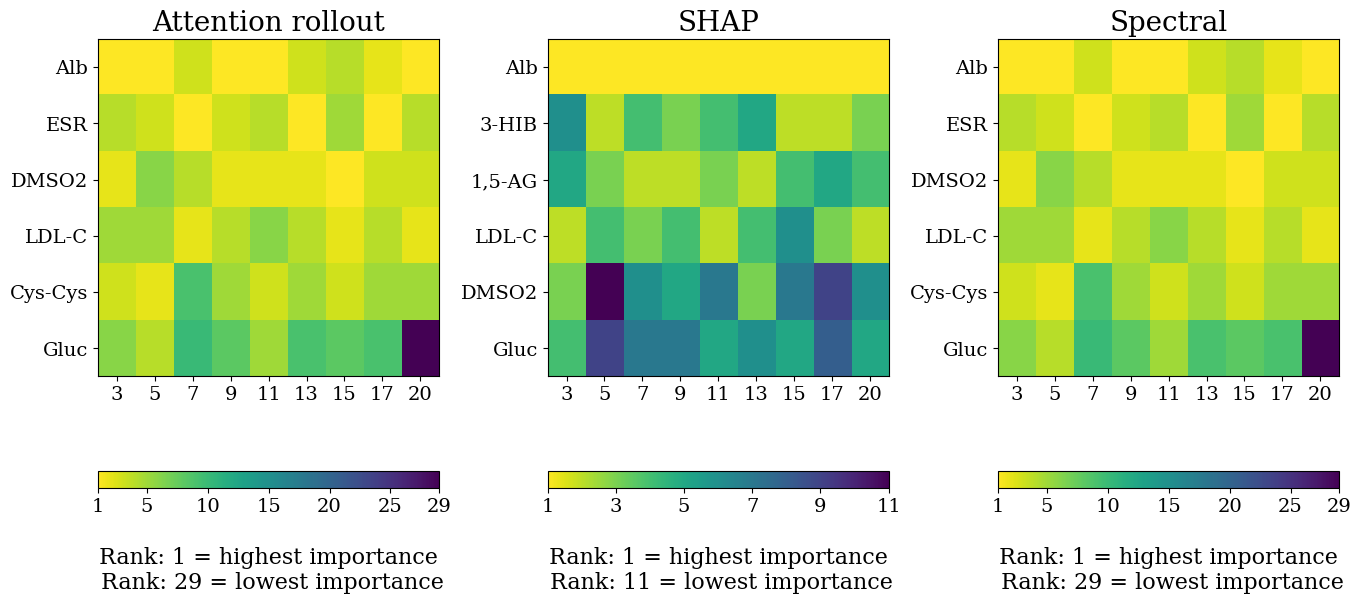

In [54]:
score_sets = [("Attention rollout", attn_scores), 
              ("SHAP", shap_scores), 
              ("Spectral", pca_scores)]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 6), constrained_layout=True)

for ax, (title, score_dict) in zip(axes, score_sets):

    rank_matrix, selected_features = compute_rank_matrix(score_dict, NUM_LAYERS, top_k=6)

    im = ax.imshow(rank_matrix, aspect="auto", cmap="viridis_r")

    ax.set_title(title, fontsize=20)

    ax.set_xticks(np.arange(len(NUM_LAYERS)))
    ax.set_xticklabels(NUM_LAYERS, fontsize=14)

    ax.set_yticks(np.arange(len(selected_features)))
    ax.set_yticklabels([feature_abbrev[i] for i in selected_features], fontsize=14)

    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", 
                        fraction=0.08, pad=0.18)

    cbar.set_label("Rank: 1 = highest importance")
    if title=="SHAP":
        cbar.set_ticks([1, 3, 5, 7, 9, 11])
        cbar.set_ticklabels([1, 3, 5, 7, 9, 11], fontsize=14)
        cbar.set_label("\n Rank: 1 = highest importance \n Rank: 11 = lowest importance",
                      fontsize=16)
    else:
        cbar.set_ticks([1, 5, 10, 15, 20, 25, 29])
        cbar.set_ticklabels([1, 5, 10, 15, 20, 25, 29], fontsize=14)
        cbar.set_label("\n Rank: 1 = highest importance \n Rank: 29 = lowest importance", 
                      fontsize=16)


plt.savefig("Results/feature_importance_plots/ranking_heatmaps.pdf", bbox_inches="tight")
plt.show()